In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [2]:
data  = pd.read_csv("EURUSD_M15_2019-2025.csv", parse_dates = ['time'], index_col = 'time')

In [3]:
data = data[:'2025-02']

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 153409 entries, 2019-01-01 22:00:00 to 2025-02-28 21:45:00
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   price   153409 non-null  float64
 1   spread  153409 non-null  float64
dtypes: float64(2)
memory usage: 3.5 MB


In [5]:
data['returns'] = np.log(data['price'] / data['price'].shift(1))

In [6]:
window = 50

In [7]:
df = data.copy()
df["dir"] = np.where(df["returns"] > 0, 1, 0)
df["sma"] = df['price'].rolling(window).mean() - df['price'].rolling(150).mean()
df["boll"] = (df['price'] - df['price'].rolling(window).mean()) / df['price'].rolling(window).std()
df["min"] = df['price'].rolling(window).min() / df['price'] - 1
df["max"] = df['price'].rolling(window).max() / df['price'] - 1
df["mom"] = df["returns"].rolling(3).mean()
df["vol"] = df["returns"].rolling(window).std()
df.dropna(inplace = True)

In [8]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol
time,,,,,,,,,,
2019-01-03 11:15:00,1.13547,0.00014,-0.00017,0,-0.00337,-0.41014,-0.00372,0.00244,-0.00045,0.00063
2019-01-03 11:30:00,1.13498,0.00013,-0.00043,0,-0.00328,-0.76137,-0.00329,0.00287,-0.00055,0.00060
2019-01-03 11:45:00,1.13416,0.00015,-0.00072,0,-0.00320,-1.34227,-0.00257,0.00360,-0.00044,0.00061
2019-01-03 12:00:00,1.13437,0.00014,0.00019,1,-0.00310,-1.23208,-0.00275,0.00341,-0.00032,0.00061
2019-01-03 12:15:00,1.13482,0.00013,0.00040,1,-0.00295,-1.09565,-0.00099,0.00301,-0.00005,0.00054
...,...,...,...,...,...,...,...,...,...,...
2025-02-28 20:45:00,1.03750,0.00016,0.00071,1,-0.00157,-1.36125,-0.00110,0.00407,0.00022,0.00057
2025-02-28 21:00:00,1.03744,0.00017,-0.00006,0,-0.00156,-1.34241,-0.00104,0.00413,0.00027,0.00057
2025-02-28 21:15:00,1.03750,0.00015,0.00006,1,-0.00154,-1.25171,-0.00110,0.00407,0.00024,0.00057


In [9]:
lags = 5

In [10]:
col = []
features = ["sma", "boll", "min", "max", "mom", "vol","dir"]
for feature in features:
    for lag in range(1, lags + 1):
        col.append(f"{feature}_lag{lag}")
        df[f"{feature}_lag{lag}"] = df[feature].shift(lag)
df.dropna(inplace = True)

In [11]:
df

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-28 20:45:00,1.03750,0.00016,0.00071,1,-0.00157,-1.36125,-0.00110,0.00407,0.00022,0.00057,...,0.00056,0.00056,0.00057,0.00057,0.00057,1.00000,0.00000,1.00000,1.00000,0.00000
2025-02-28 21:00:00,1.03744,0.00017,-0.00006,0,-0.00156,-1.34241,-0.00104,0.00413,0.00027,0.00057,...,0.00057,0.00056,0.00056,0.00057,0.00057,1.00000,1.00000,0.00000,1.00000,1.00000
2025-02-28 21:15:00,1.03750,0.00015,0.00006,1,-0.00154,-1.25171,-0.00110,0.00407,0.00024,0.00057,...,0.00057,0.00057,0.00056,0.00056,0.00057,0.00000,1.00000,1.00000,0.00000,1.00000


In [12]:
len(col)

35

In [13]:
len(df)

153255

In [14]:
split = int(len(df)*0.66)
split

101148

In [15]:
train = df.iloc[:split].copy()
train

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,1.13535,0.00012,0.00047,1,-0.00284,-0.71579,-0.00125,0.00255,0.00035,0.00045,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,1.13436,0.00012,-0.00087,0,-0.00276,-1.56972,-0.00038,0.00342,-0.00000,0.00046,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,1.13483,0.00044,0.00041,1,-0.00266,-1.21306,-0.00075,0.00300,0.00000,0.00046,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,1.13506,0.00021,0.00020,1,-0.00257,-1.06133,-0.00079,0.00280,-0.00009,0.00046,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,1.13574,0.00013,0.00060,1,-0.00248,-0.47358,-0.00139,0.00220,0.00041,0.00046,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-25 23:15:00,1.09212,0.00017,0.00013,1,0.00101,1.28287,-0.00538,0.00000,0.00015,0.00057,...,0.00057,0.00057,0.00057,0.00060,0.00061,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-25 23:30:00,1.09216,0.00017,0.00004,1,0.00108,1.25964,-0.00542,0.00000,0.00021,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00060,1.00000,1.00000,0.00000,1.00000,0.00000
2023-01-25 23:45:00,1.09207,0.00016,-0.00008,0,0.00115,1.17533,-0.00534,0.00008,0.00003,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,1.00000,1.00000,1.00000,0.00000,1.00000


In [16]:
test = df.iloc[split:].copy()
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-26 00:30:00,1.09185,0.00016,-0.00030,0,0.00137,0.95060,-0.00505,0.00038,-0.00007,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,1.00000,0.00000,1.00000,1.00000
2023-01-26 00:45:00,1.09158,0.00015,-0.00025,0,0.00144,0.76837,-0.00465,0.00063,-0.00021,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,0.00000,1.00000,0.00000,1.00000
2023-01-26 01:00:00,1.09116,0.00015,-0.00038,0,0.00150,0.47703,-0.00361,0.00102,-0.00031,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,0.00000,0.00000,1.00000,0.00000
2023-01-26 01:15:00,1.09080,0.00015,-0.00033,0,0.00154,0.20203,-0.00328,0.00135,-0.00032,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,0.00000,0.00000,0.00000,1.00000
2023-01-26 01:30:00,1.09160,0.00015,0.00073,1,0.00159,0.72651,-0.00401,0.00061,0.00001,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,0.00000,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-28 20:45:00,1.03750,0.00016,0.00071,1,-0.00157,-1.36125,-0.00110,0.00407,0.00022,0.00057,...,0.00056,0.00056,0.00057,0.00057,0.00057,1.00000,0.00000,1.00000,1.00000,0.00000
2025-02-28 21:00:00,1.03744,0.00017,-0.00006,0,-0.00156,-1.34241,-0.00104,0.00413,0.00027,0.00057,...,0.00057,0.00056,0.00056,0.00057,0.00057,1.00000,1.00000,0.00000,1.00000,1.00000
2025-02-28 21:15:00,1.03750,0.00015,0.00006,1,-0.00154,-1.25171,-0.00110,0.00407,0.00024,0.00057,...,0.00057,0.00057,0.00056,0.00056,0.00057,0.00000,1.00000,1.00000,0.00000,1.00000


In [17]:
train[col] 

,sma_lag1,sma_lag2,sma_lag3,sma_lag4,sma_lag5,boll_lag1,boll_lag2,boll_lag3,boll_lag4,boll_lag5,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,-0.00295,-0.00310,-0.00320,-0.00328,-0.00337,-1.09565,-1.23208,-1.34227,-0.76137,-0.41014,...,0.00054,0.00061,0.00061,0.00060,0.00063,1.00000,1.00000,0.00000,0.00000,0.00000
2019-01-03 12:45:00,-0.00284,-0.00295,-0.00310,-0.00320,-0.00328,-0.71579,-1.09565,-1.23208,-1.34227,-0.76137,...,0.00045,0.00054,0.00061,0.00061,0.00060,1.00000,1.00000,1.00000,0.00000,0.00000
2019-01-03 13:00:00,-0.00276,-0.00284,-0.00295,-0.00310,-0.00320,-1.56972,-0.71579,-1.09565,-1.23208,-1.34227,...,0.00046,0.00045,0.00054,0.00061,0.00061,0.00000,1.00000,1.00000,1.00000,0.00000
2019-01-03 13:15:00,-0.00266,-0.00276,-0.00284,-0.00295,-0.00310,-1.21306,-1.56972,-0.71579,-1.09565,-1.23208,...,0.00046,0.00046,0.00045,0.00054,0.00061,1.00000,0.00000,1.00000,1.00000,1.00000
2019-01-03 13:30:00,-0.00257,-0.00266,-0.00276,-0.00284,-0.00295,-1.06133,-1.21306,-1.56972,-0.71579,-1.09565,...,0.00046,0.00046,0.00046,0.00045,0.00054,1.00000,1.00000,0.00000,1.00000,1.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-25 23:15:00,0.00094,0.00087,0.00081,0.00075,0.00071,1.25676,1.04526,1.17002,1.16532,1.21377,...,0.00057,0.00057,0.00057,0.00060,0.00061,1.00000,0.00000,1.00000,0.00000,1.00000
2023-01-25 23:30:00,0.00101,0.00094,0.00087,0.00081,0.00075,1.28287,1.25676,1.04526,1.17002,1.16532,...,0.00057,0.00057,0.00057,0.00057,0.00060,1.00000,1.00000,0.00000,1.00000,0.00000
2023-01-25 23:45:00,0.00108,0.00101,0.00094,0.00087,0.00081,1.25964,1.28287,1.25676,1.04526,1.17002,...,0.00057,0.00057,0.00057,0.00057,0.00057,1.00000,1.00000,1.00000,0.00000,1.00000


In [18]:
mu, std = train.mean(), train.std()

In [19]:
std

price       0.05947
spread      0.00010
returns     0.00050
dir         0.49994
sma         0.00237
boll        1.41934
min         0.00227
max         0.00224
mom         0.00028
vol         0.00025
sma_lag1    0.00237
sma_lag2    0.00237
sma_lag3    0.00237
sma_lag4    0.00237
sma_lag5    0.00237
boll_lag1   1.41934
boll_lag2   1.41934
boll_lag3   1.41934
boll_lag4   1.41934
boll_lag5   1.41934
min_lag1    0.00227
min_lag2    0.00227
min_lag3    0.00227
min_lag4    0.00227
min_lag5    0.00227
max_lag1    0.00224
max_lag2    0.00224
max_lag3    0.00224
max_lag4    0.00224
max_lag5    0.00224
mom_lag1    0.00028
mom_lag2    0.00028
mom_lag3    0.00028
mom_lag4    0.00028
mom_lag5    0.00028
vol_lag1    0.00025
vol_lag2    0.00025
vol_lag3    0.00025
vol_lag4    0.00025
vol_lag5    0.00025
dir_lag1    0.49994
dir_lag2    0.49994
dir_lag3    0.49994
dir_lag4    0.49994
dir_lag5    0.49994
dtype: float64

In [20]:
train_s = (train - mu) / std
train_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2019-01-03 12:30:00,0.19793,-0.40976,0.93254,1.01554,-1.18833,-0.49967,0.36141,0.20515,1.23341,0.04089,...,0.40406,0.68297,0.69816,0.67956,0.78815,1.01552,1.01552,-0.98471,-0.98469,-0.98467
2019-01-03 12:45:00,0.18128,-0.40976,-1.74010,-0.98469,-1.15230,-1.10131,0.74528,0.59585,-0.00903,0.09784,...,0.04089,0.40406,0.68296,0.69815,0.67955,1.01552,1.01552,1.01552,-0.98469,-0.98467
2019-01-03 13:00:00,0.18919,2.93778,0.82741,1.01554,-1.11193,-0.85002,0.58236,0.41028,0.01168,0.10779,...,0.09784,0.04089,0.40406,0.68296,0.69815,-0.98471,1.01552,1.01552,1.01554,-0.98467
2019-01-03 13:15:00,0.19305,0.53173,0.40516,1.01554,-1.07171,-0.74311,0.56303,0.31953,-0.29881,0.11080,...,0.10779,0.09784,0.04089,0.40405,0.68296,1.01552,-0.98471,1.01552,1.01554,1.01556
2019-01-03 13:30:00,0.20449,-0.30515,1.19592,1.01554,-1.03351,-0.32902,0.29956,0.05143,1.42976,0.10598,...,0.11080,0.10779,0.09784,0.04089,0.40405,1.01552,1.01552,-0.98471,1.01554,1.01556
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-01-25 23:15:00,-0.52894,0.11329,0.25659,1.01554,0.43511,0.90849,-1.45884,-0.93148,0.51781,0.54405,...,0.54594,0.55375,0.55125,0.66216,0.68443,1.01552,-0.98471,1.01552,-0.98469,1.01556
2023-01-25 23:30:00,-0.52827,0.11329,0.07384,1.01554,0.46381,0.89213,-1.47488,-0.93148,0.73306,0.54373,...,0.54405,0.54594,0.55375,0.55125,0.66215,1.01552,1.01552,-0.98471,1.01554,-0.98467
2023-01-25 23:45:00,-0.52978,0.00868,-0.16370,-0.98469,0.49448,0.83272,-1.43878,-0.89468,0.09815,0.54024,...,0.54373,0.54405,0.54594,0.55375,0.55125,1.01552,1.01552,1.01552,-0.98469,1.01556


In [21]:
train_s.describe()

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
count,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,...,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000,101148.00000
mean,-0.00000,0.00000,0.00000,-0.00000,-0.00000,0.00000,0.00000,-0.00000,-0.00000,-0.00000,...,0.00000,-0.00000,-0.00000,-0.00000,-0.00000,0.00000,0.00000,0.00000,-0.00000,0.00000
std,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,...,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000,1.00000
min,-2.85230,-0.61898,-23.01627,-0.98469,-5.06951,-4.45639,-10.88689,-0.93148,-18.30532,-1.49716,...,-1.49716,-1.49716,-1.49716,-1.49716,-1.49716,-0.98471,-0.98471,-0.98471,-0.98469,-0.98467
25%,-0.52171,-0.30515,-0.38970,-0.98469,-0.55943,-0.73595,-0.31834,-0.68411,-0.39675,-0.66932,...,-0.66932,-0.66932,-0.66932,-0.66932,-0.66933,-0.98471,-0.98471,-0.98471,-0.98469,-0.98467
50%,0.01760,-0.20054,0.00076,-0.98469,-0.00837,-0.00100,0.30783,-0.29949,0.00132,-0.24611,...,-0.24611,-0.24611,-0.24612,-0.24612,-0.24612,-0.98471,-0.98471,-0.98471,-0.98469,-0.98467
75%,0.86435,0.00868,0.39197,1.01554,0.55524,0.74441,0.66222,0.33076,0.39227,0.38474,...,0.38474,0.38474,0.38473,0.38473,0.38473,1.01552,1.01552,1.01552,1.01554,1.01556
max,1.86806,8.79597,31.96491,1.01554,5.00005,4.40417,0.91221,10.04416,20.81534,8.41660,...,8.41661,8.41660,8.41659,8.41658,8.41656,1.01552,1.01552,1.01552,1.01554,1.01556


In [22]:
from DNNModel import *

In [23]:
# fitting a DNN model with 3 Hidden Layers (50 nodes each) and dropout regularization

set_seeds(100)
model = create_model(hl = 3, hu = 50, dropout = True, input_dim = len(col))
model.fit(x = train_s[col], y = train["dir"], epochs = 50, verbose = False,
          validation_split = 0.2, shuffle = False, class_weight = cw(train))

d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.evaluate(train_s[col], train["dir"])

3161/3161 ━━━━━━━━━━━━━━━━━━━━ 3s 993us/step - accuracy: 0.5271 - loss: 0.6914


[0.6913902759552002, 0.5270988941192627]

In [25]:
pred = model.predict(train_s[col])
pred

3161/3161 ━━━━━━━━━━━━━━━━━━━━ 3s 850us/step


array([[0.50236595],
       [0.45072556],
       [0.5123193 ],
       ...,
       [0.480344  ],
       [0.50795376],
       [0.47905672]], shape=(101148, 1), dtype=float32)

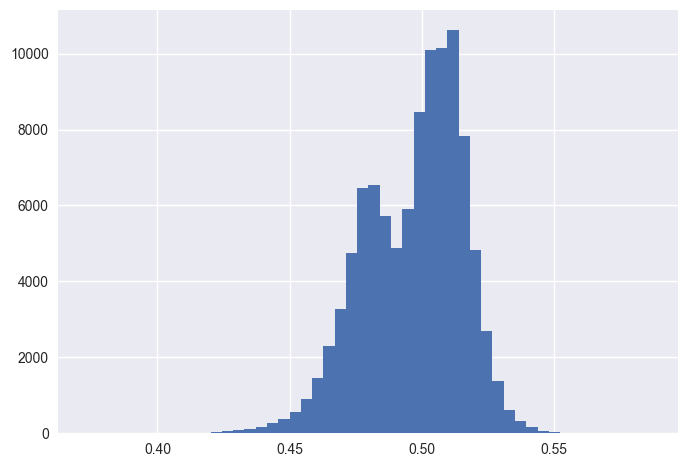

In [26]:
plt.hist(pred, bins = 50)
plt.show()

## Out-Sample Prediction and Forward Testing

In [27]:
test

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-26 00:30:00,1.09185,0.00016,-0.00030,0,0.00137,0.95060,-0.00505,0.00038,-0.00007,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,1.00000,0.00000,1.00000,1.00000
2023-01-26 00:45:00,1.09158,0.00015,-0.00025,0,0.00144,0.76837,-0.00465,0.00063,-0.00021,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,0.00000,1.00000,0.00000,1.00000
2023-01-26 01:00:00,1.09116,0.00015,-0.00038,0,0.00150,0.47703,-0.00361,0.00102,-0.00031,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,0.00000,0.00000,1.00000,0.00000
2023-01-26 01:15:00,1.09080,0.00015,-0.00033,0,0.00154,0.20203,-0.00328,0.00135,-0.00032,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,0.00000,0.00000,0.00000,1.00000
2023-01-26 01:30:00,1.09160,0.00015,0.00073,1,0.00159,0.72651,-0.00401,0.00061,0.00001,0.00057,...,0.00057,0.00057,0.00057,0.00057,0.00057,0.00000,0.00000,0.00000,0.00000,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-28 20:45:00,1.03750,0.00016,0.00071,1,-0.00157,-1.36125,-0.00110,0.00407,0.00022,0.00057,...,0.00056,0.00056,0.00057,0.00057,0.00057,1.00000,0.00000,1.00000,1.00000,0.00000
2025-02-28 21:00:00,1.03744,0.00017,-0.00006,0,-0.00156,-1.34241,-0.00104,0.00413,0.00027,0.00057,...,0.00057,0.00056,0.00056,0.00057,0.00057,1.00000,1.00000,0.00000,1.00000,1.00000
2025-02-28 21:15:00,1.03750,0.00015,0.00006,1,-0.00154,-1.25171,-0.00110,0.00407,0.00024,0.00057,...,0.00057,0.00057,0.00056,0.00056,0.00057,0.00000,1.00000,1.00000,0.00000,1.00000


In [28]:
test_s = (test - mu) / std
test_s

,price,spread,returns,dir,sma,boll,min,max,mom,vol,...,vol_lag1,vol_lag2,vol_lag3,vol_lag4,vol_lag5,dir_lag1,dir_lag2,dir_lag3,dir_lag4,dir_lag5
time,,,,,,,,,,,,,,,,,,,,,
2023-01-26 00:30:00,-0.53348,0.00868,-0.60229,-0.98469,0.58523,0.67439,-1.31019,-0.75971,-0.23538,0.54519,...,0.53778,0.53593,0.54023,0.54373,0.54404,-0.98471,1.01552,-0.98471,1.01554,1.01556
2023-01-26 00:45:00,-0.53802,-0.09593,-0.49278,-0.98469,0.61579,0.54600,-1.13726,-0.64922,-0.74110,0.53130,...,0.54519,0.53778,0.53593,0.54023,0.54372,-0.98471,-0.98471,1.01552,-0.98469,1.01556
2023-01-26 01:00:00,-0.54508,-0.09593,-0.76721,-0.98469,0.64270,0.34073,-0.67795,-0.47724,-1.09643,0.54755,...,0.53130,0.54519,0.53777,0.53592,0.54023,-0.98471,-0.98471,-0.98471,1.01554,-0.98467
2023-01-26 01:15:00,-0.55113,-0.09593,-0.65774,-0.98469,0.65995,0.14698,-0.53313,-0.32972,-1.12907,0.52000,...,0.54755,0.53130,0.54519,0.53777,0.53592,-0.98471,-0.98471,-0.98471,-0.98469,1.01556
2023-01-26 01:30:00,-0.53768,-0.09593,1.46378,1.01554,0.67787,0.51651,-0.85482,-0.65741,0.02285,0.54500,...,0.52000,0.54755,0.53130,0.54518,0.53777,-0.98471,-0.98471,-0.98471,-0.98469,-0.98467
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-28 20:45:00,-1.44732,0.00868,1.42461,1.01554,-0.65287,-0.95443,0.42832,0.88477,0.79428,0.54329,...,0.50053,0.50579,0.51947,0.53141,0.53409,1.01552,-0.98471,1.01552,1.01554,-0.98467
2025-02-28 21:00:00,-1.44833,0.11329,-0.11465,-0.98469,-0.64540,-0.94115,0.45376,0.91070,0.96433,0.54066,...,0.54330,0.50053,0.50579,0.51947,0.53141,1.01552,1.01552,-0.98471,1.01554,1.01556
2025-02-28 21:15:00,-1.44732,-0.09593,0.11617,1.01554,-0.63927,-0.87725,0.42832,0.88477,0.83961,0.53820,...,0.54066,0.54329,0.50053,0.50579,0.51947,-0.98471,1.01552,1.01552,-0.98469,1.01556


In [29]:
model.evaluate(test_s[col], test["dir"])

1629/1629 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.5162 - loss: 0.6925


[0.692540168762207, 0.5162070393562317]

In [30]:
pred = model.predict(train_s[col])
pred

3161/3161 ━━━━━━━━━━━━━━━━━━━━ 2s 756us/step


array([[0.50236595],
       [0.45072556],
       [0.5123193 ],
       ...,
       [0.480344  ],
       [0.50795376],
       [0.47905672]], shape=(101148, 1), dtype=float32)

(array([1.0000e+00, 1.0000e+00, 5.0000e+00, 1.0000e+00, 1.0000e+00,
        4.0000e+00, 7.0000e+00, 1.2000e+01, 1.0000e+01, 2.0000e+01,
        9.0000e+00, 2.6000e+01, 4.8000e+01, 8.2000e+01, 1.0600e+02,
        1.7800e+02, 2.6700e+02, 3.6900e+02, 5.4800e+02, 8.9100e+02,
        1.4680e+03, 2.3060e+03, 3.2830e+03, 4.7500e+03, 6.4690e+03,
        6.5350e+03, 5.7130e+03, 4.8730e+03, 5.8970e+03, 8.4590e+03,
        1.0088e+04, 1.0153e+04, 1.0624e+04, 7.8340e+03, 4.8220e+03,
        2.7020e+03, 1.3680e+03, 6.2300e+02, 3.1800e+02, 1.5500e+02,
        6.7000e+01, 2.8000e+01, 9.0000e+00, 1.0000e+01, 2.0000e+00,
        4.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([0.37324265, 0.37750521, 0.38176778, 0.38603035, 0.39029291,
        0.39455545, 0.39881802, 0.40308058, 0.40734315, 0.41160572,
        0.41586828, 0.42013085, 0.42439342, 0.42865598, 0.43291855,
        0.43718112, 0.44144368, 0.44570625, 0.44996879, 0.45423135,
        0.45849392, 0.46275648, 0.46701905, 0.

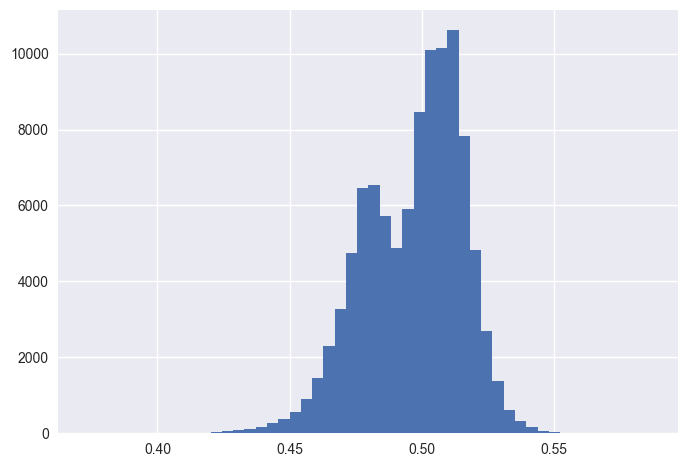

In [31]:
plt.hist(pred, bins = 50)

In [32]:
test['proba'] = model.predict(test_s[col])  

1629/1629 ━━━━━━━━━━━━━━━━━━━━ 1s 694us/step


In [33]:
test["position"] = np.where(test.proba < 0.47, -1, np.nan) # 1. short where proba < 0.47

In [34]:
test["position"] = np.where(test.proba > 0.53, 1, test.position) # 2. long where proba > 0.53

In [35]:
test["hour"] = test.index.hour

In [36]:
test["position"] = np.where(~test.hour.between(12, 16), 0, test.position) # 3. neutral in non-busy hours

In [37]:
test["position"] = test.position.ffill().fillna(0) # 4. in all other cases: hold position

In [38]:
test.position.value_counts(dropna = False)

position
0.00000     46803
-1.00000     3811
1.00000      1493
Name: count, dtype: int64

In [39]:
test["strategy"] = test["position"] * test["returns"]

In [40]:
test["creturns"] = test["returns"].cumsum().apply(np.exp)
test["cstrategy"] = test["strategy"].cumsum().apply(np.exp)

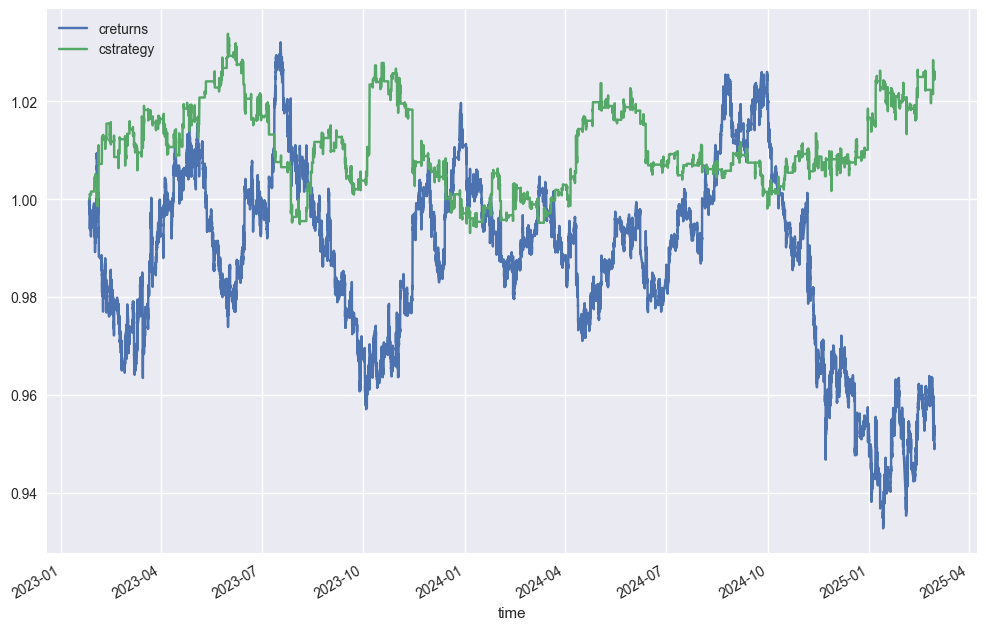

In [41]:
test[["creturns", "cstrategy"]].plot(figsize = (12, 8))
plt.show()

In [42]:
ptc = 0.00005 

In [43]:
test['trades'] = test.position.diff().abs()

In [44]:
test['trades'].value_counts()

trades
0.00000    51256
1.00000      752
2.00000       98
Name: count, dtype: int64

In [45]:
test['strategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

In [46]:
test['cstrategy_net'] = (test['strategy'] - test['trades'] * ptc).cumsum().apply(np.exp)

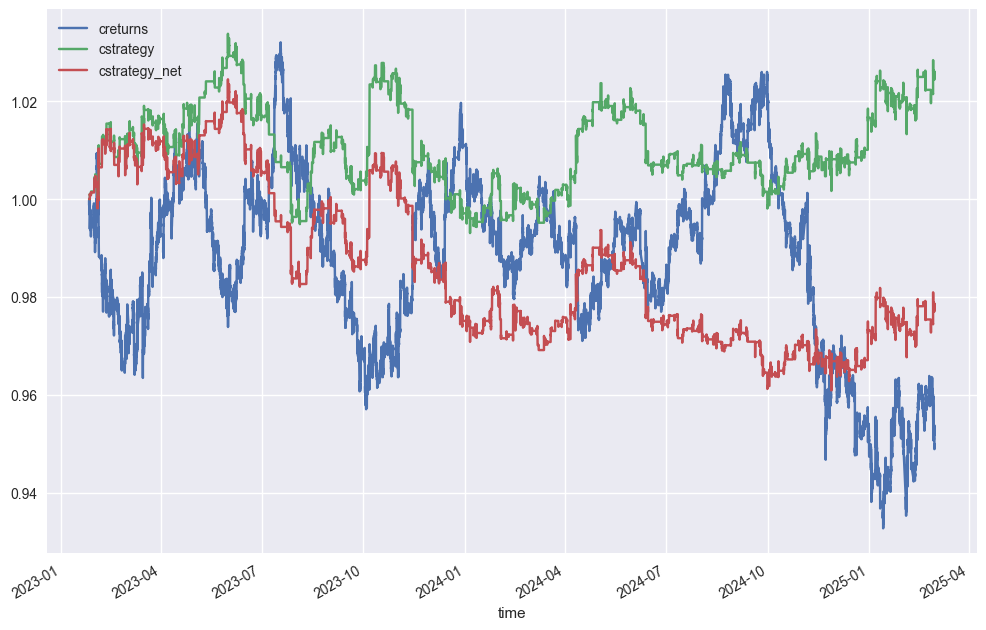

In [47]:
test[['creturns', 'cstrategy', 'cstrategy_net']].plot(figsize = (12, 8))
plt.show()


## XAI Decision Filtering Gate (SHAP)

This section adds a **risk-management gate** in front of the DNN’s trade decisions.

- The DNN produces a position signal (`test["position"]`) at every timestamp.
- A trade only happens when the position **changes** (captured by `test["trades"]`).
- The XAI gate runs **only at trade events** and uses **local SHAP feature importance** to decide whether a *new entry* is sufficiently well-explained.
- **Exits are always allowed** (reduces risk); **entries are filtered** (reduces low-quality / weakly-explained trades).

Outcome: we get a new position series `test["position_xai"]` and a net equity curve `test["cstrategy_net_xai"]` to compare against the baseline `test["cstrategy_net"]`.

In [63]:
# If needed:
# !pip install shap

import shap

# Gate hyperparameters (tune these)
TOP_N = 3
N_BACKGROUND = 200         # SHAP background sample size
N_CALIB = 300             # number of entry/flip events used to calibrate threshold
SHAP_QUANTILE = 0.75      # keep only the strongest ~25% explanations (higher => fewer trades)
PROBA_MARGIN = 0.05       # additional confidence margin around 0.5 for allowing entries
EXCLUDE_TOP1_PREFIXES = ("dir_",)  # treat these as weak/less-informative top drivers

# Build SHAP explainer on training distribution
background = train_s[col].sample(N_BACKGROUND, random_state=42).values
explainer = shap.DeepExplainer(model, background)


def _extract_shap_vector(shap_values):
    """Return a 1D SHAP vector for the (single) model output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr).reshape(-1)


def _top_shap_summary(instance_1d, *, top_n=TOP_N):
    """Compute local SHAP summary for one instance."""
    instance_2d = instance_1d.reshape(1, -1)
    shap_values = explainer.shap_values(instance_2d, check_additivity=False)
    sv = _extract_shap_vector(shap_values)

    abs_sv = np.abs(sv)
    top_idx = np.argsort(abs_sv)[::-1][:top_n]
    top_features = [col[int(i)] for i in top_idx]
    top_shap = sv[top_idx]

    return {
        "sv": sv,
        "sv_sum": float(sv.sum()),
        "top_idx": top_idx,
        "top_features": top_features,
        "top_shap": [float(x) for x in top_shap],
        "top_abs": [float(x) for x in abs_sv[top_idx]],
        "top1_abs": float(abs_sv[top_idx[0]]),
    }


def calibrate_shap_threshold(test_df, test_scaled, *, quantile=SHAP_QUANTILE, n_calib=N_CALIB):
    """
    Calibrate an absolute-SHAP threshold from the distribution of top-1 SHAP magnitudes
    on (a sample of) entry/flip events.

    Higher threshold => fewer trades (stricter risk filter).
    """
    # Events where the baseline strategy changes position AND desires a non-zero position
    trade_event = test_df["trades"].fillna(0) > 0
    entry_like = trade_event & (test_df["position"].fillna(0) != 0)
    event_idx = test_df.index[entry_like]

    if len(event_idx) == 0:
        return 0.0

    # Sample for speed
    if len(event_idx) > n_calib:
        event_idx = event_idx[:n_calib]

    top1_abs_list = []
    for idx in event_idx:
        instance = test_scaled.loc[idx, col].values
        summ = _top_shap_summary(instance, top_n=TOP_N)
        top1_abs_list.append(summ["top1_abs"])

    thr = float(np.quantile(np.array(top1_abs_list), quantile))
    return thr


def xai_gate_entry(instance_1d, desired_pos, proba, *, shap_threshold, top_n=TOP_N):
    """
    Decide whether to ALLOW a *new entry* (desired_pos in {-1, +1}) based on local SHAP.

    Checks:
    - confidence: proba must be far enough from 0.5 (PROBA_MARGIN)
    - explanation strength: top-1 |SHAP| must exceed calibrated shap_threshold
    - explanation direction: sum(SHAP) should align with desired direction
    - explanation quality: avoid trivial top driver(s) like dir_lag* (optional)

    Returns: allow(bool), info(dict)
    """
    desired_pos = int(desired_pos)
    proba = float(proba)

    # Confidence check (acts like a second-stage filter)
    if desired_pos == 1:
        proba_ok = proba >= (0.5 + PROBA_MARGIN)
    else:
        proba_ok = proba <= (0.5 - PROBA_MARGIN)

    summ = _top_shap_summary(instance_1d, top_n=top_n)
    sv_sum = summ["sv_sum"]

    direction_ok = (desired_pos == 1 and sv_sum > 0) or (desired_pos == -1 and sv_sum < 0)
    magnitude_ok = summ["top1_abs"] >= float(shap_threshold)

    top1 = summ["top_features"][0]
    top1_ok = not any(top1.startswith(p) for p in EXCLUDE_TOP1_PREFIXES)

    allow = bool(proba_ok and direction_ok and magnitude_ok and top1_ok)

    info = {
        "proba": proba,
        "desired_pos": desired_pos,
        "sv_sum": sv_sum,
        "top_features": summ["top_features"],
        "top_shap": summ["top_shap"],
        "top_abs": summ["top_abs"],
        "top1_abs": summ["top1_abs"],
        "proba_ok": bool(proba_ok),
        "direction_ok": bool(direction_ok),
        "magnitude_ok": bool(magnitude_ok),
        "top1_ok": bool(top1_ok),
        "shap_threshold": float(shap_threshold),
    }
    return allow, info


def format_gate_explanation(prev_pos, desired_pos, final_pos, info, allow):
    tf = info.get("top_features", [])
    ts = info.get("top_shap", [])
    parts = [
        f"prev={prev_pos}, desired={desired_pos}, final={final_pos}",
        f"proba={info.get('proba', np.nan):.3f}, shap_sum={info.get('sv_sum', np.nan):+.4f}, top1_abs={info.get('top1_abs', np.nan):.4f}",
        f"shap_threshold={info.get('shap_threshold', np.nan):.4f}",
        "top features: " + ", ".join([f"{f}({v:+.4f})" for f, v in zip(tf, ts)]),
        f"checks: proba={info.get('proba_ok')} direction={info.get('direction_ok')} magnitude={info.get('magnitude_ok')} top1_ok={info.get('top1_ok')}",
        "DECISION: " + ("ALLOW" if allow else "DENY"),
    ]
    return "\n".join(parts)

d:\anaconda3\envs\mlops_test\lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 35))']
  warnings.warn(msg)


In [64]:
# Apply XAI gate only when the baseline strategy would trade
pos_target = test["position"].copy()

# Calibrate SHAP threshold from entry/flip events
SHAP_THRESHOLD = calibrate_shap_threshold(test, test_s, quantile=SHAP_QUANTILE, n_calib=N_CALIB)
print("Calibrated SHAP_THRESHOLD:", SHAP_THRESHOLD)

# Construct position_xai sequentially:
# - Exits to 0 are always allowed
# - Entries to +/-1 are filtered by SHAP + confidence checks
# - Flips become: exit (allowed) then optional entry (gated)

position_xai = pd.Series(index=test.index, dtype=float)
position_xai.iloc[0] = float(pos_target.iloc[0])

trade_event = test["trades"].fillna(0) > 0

gate_log = []

for i in range(1, len(test)):
    idx = test.index[i]
    prev = float(position_xai.iloc[i - 1])
    desired = float(pos_target.iloc[i])

    # Default: hold
    final_pos = prev
    action = "hold"
    allow = True

    proba = float(test.loc[idx, "proba"])
    info = {"proba": proba, "desired_pos": int(desired), "sv_sum": np.nan, "top_features": [], "top_shap": [], "top_abs": [], "top1_abs": np.nan, "proba_ok": True, "direction_ok": True, "magnitude_ok": True, "top1_ok": True, "shap_threshold": float(SHAP_THRESHOLD)}

    if trade_event.iloc[i]:
        # Model wants to change position here
        if desired == 0:
            action = "exit"
            final_pos = 0.0
            allow = True

        elif prev != 0 and np.sign(prev) != np.sign(desired):
            # Flip: always exit; entry is gated
            action = "flip"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else 0.0

        else:
            # Entry from flat, or re-entry after being flat
            action = "entry"
            instance = test_s.loc[idx, col].values
            allow_entry, info = xai_gate_entry(instance, int(desired), proba, shap_threshold=SHAP_THRESHOLD, top_n=TOP_N)
            allow = allow_entry
            final_pos = float(desired) if allow_entry else prev

    position_xai.iloc[i] = final_pos

    if trade_event.iloc[i]:
        gate_log.append({
            "time": idx,
            "action": action,
            "prev_pos": prev,
            "desired_pos": desired,
            "final_pos": final_pos,
            "allow": bool(allow),
            "proba": info.get("proba", np.nan),
            "sv_sum": info.get("sv_sum", np.nan),
            "top1": info.get("top_features", [None])[0] if info.get("top_features") else None,
            "top1_abs": info.get("top1_abs", np.nan),
            "top1_shap": info.get("top_shap", [np.nan])[0] if info.get("top_shap") else np.nan,
            "proba_ok": info.get("proba_ok", True),
            "direction_ok": info.get("direction_ok", True),
            "magnitude_ok": info.get("magnitude_ok", True),
            "top1_ok": info.get("top1_ok", True),
            "shap_threshold": info.get("shap_threshold", np.nan),
            "explanation": format_gate_explanation(prev, desired, final_pos, info, allow),
        })

# Attach to test
position_xai = position_xai.ffill().fillna(0)
test["position_xai"] = position_xai

# Trades and performance with gate
test["trades_xai"] = test["position_xai"].diff().abs().fillna(0)
test["strategy_xai"] = test["position_xai"] * test["returns"]
test["cstrategy_xai"] = test["strategy_xai"].cumsum().apply(np.exp)
test["cstrategy_net_xai"] = (test["strategy_xai"] - test["trades_xai"] * ptc).cumsum().apply(np.exp)

# Gate log table
gate_log_df = pd.DataFrame(gate_log).set_index("time")
gate_log_df.head()

d:\anaconda3\envs\mlops_test\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(400, 35))']
  warnings.warn(msg)


Calibrated SHAP_THRESHOLD: 0.014209890971635645


,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_abs,top1_shap,proba_ok,direction_ok,magnitude_ok,top1_ok,shap_threshold,explanation
time,,,,,,,,,,,,,,,,
2023-01-26 16:00:00,entry,0.00000,1.00000,0.00000,False,0.53247,0.03562,mom_lag1,0.02006,0.02006,False,True,True,True,0.01421,"prev=0.0, desired=1.0, final=0.0\nproba=0.532,..."
2023-01-26 17:00:00,exit,0.00000,0.00000,0.00000,True,0.52186,NaN,None,NaN,NaN,True,True,True,True,0.01421,"prev=0.0, desired=0.0, final=0.0\nproba=0.522,..."
2023-01-27 16:45:00,entry,0.00000,-1.00000,0.00000,False,0.45662,-0.04022,dir_lag1,0.01213,-0.01213,False,True,False,False,0.01421,"prev=0.0, desired=-1.0, final=0.0\nproba=0.457..."
2023-01-27 17:00:00,exit,0.00000,0.00000,0.00000,True,0.51337,NaN,None,NaN,NaN,True,True,True,True,0.01421,"prev=0.0, desired=0.0, final=0.0\nproba=0.513,..."
2023-01-30 14:45:00,entry,0.00000,-1.00000,0.00000,False,0.46605,-0.03079,dir_lag1,0.00941,-0.00941,False,True,False,False,0.01421,"prev=0.0, desired=-1.0, final=0.0\nproba=0.466..."


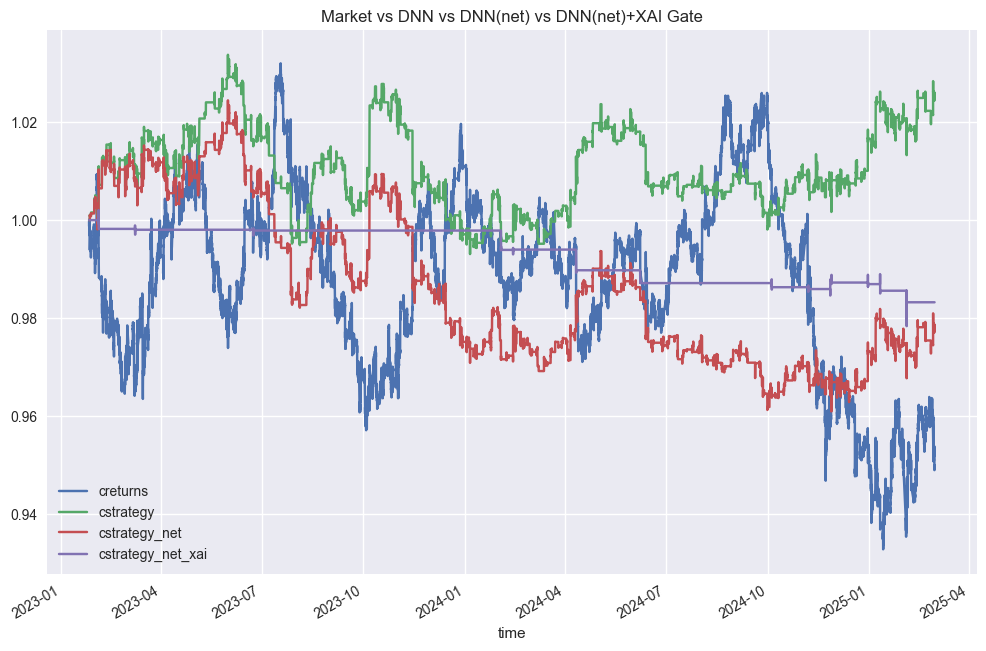

Baseline (net) ending value: 0.9784165375044012
XAI-gated (net) ending value: 0.9832054946908112
Baseline orders (sum abs pos change): 948.0
XAI orders (sum abs pos change): 28.0
Baseline trade events (bars with orders): 850
XAI trade events (bars with orders): 28
Gate evaluated events: 850
Gate allowed events: 390
Gate denied events: 460
Order reduction vs baseline: 97.05%


In [65]:
# Compare baseline vs XAI-gated strategy (net of trading costs)
compare_cols = ["creturns", "cstrategy", "cstrategy_net", "cstrategy_net_xai"]
test[compare_cols].plot(figsize=(12, 8))
plt.title("Market vs DNN vs DNN(net) vs DNN(net)+XAI Gate")
plt.show()

# Trade counts and gate stats
baseline_orders = float(test["trades"].fillna(0).sum())
xai_orders = float(test["trades_xai"].fillna(0).sum())
baseline_trade_events = int((test["trades"].fillna(0) > 0).sum())
xai_trade_events = int((test["trades_xai"].fillna(0) > 0).sum())

allowed = int(gate_log_df["allow"].sum())
denied = int((~gate_log_df["allow"]).sum())

print("Baseline (net) ending value:", float(test["cstrategy_net"].iloc[-1]))
print("XAI-gated (net) ending value:", float(test["cstrategy_net_xai"].iloc[-1]))
print("Baseline orders (sum abs pos change):", baseline_orders)
print("XAI orders (sum abs pos change):", xai_orders)
print("Baseline trade events (bars with orders):", baseline_trade_events)
print("XAI trade events (bars with orders):", xai_trade_events)
print("Gate evaluated events:", len(gate_log_df))
print("Gate allowed events:", allowed)
print("Gate denied events:", denied)

# How XAI acts as risk management
reduction = 0 if baseline_orders == 0 else 1 - (xai_orders / baseline_orders)
print("Order reduction vs baseline:", f"{reduction:.2%}")

In [66]:
# Show sample trade decisions with explanations

# Sample a few allowed and denied events (if available)
allowed_samples = gate_log_df[gate_log_df["allow"]].head(5)
denied_samples = gate_log_df[~gate_log_df["allow"]].head(5)

print("\n--- Sample ALLOWED decisions (first 5) ---")
for t, row in allowed_samples.iterrows():
    print("\nTime:", t)
    print(row["explanation"])

print("\n--- Sample DENIED decisions (first 5) ---")
for t, row in denied_samples.iterrows():
    print("\nTime:", t)
    print(row["explanation"])

# Compact table view
cols_view = ["action", "prev_pos", "desired_pos", "final_pos", "allow", "proba", "sv_sum", "top1", "top1_shap"]
gate_log_df[cols_view].head(20)


--- Sample ALLOWED decisions (first 5) ---

Time: 2023-01-26 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.522, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0142
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2023-01-27 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.513, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0142
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2023-01-30 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.528, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0142
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2023-01-31 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.507, shap_sum=+nan, top1_abs=nan
shap_threshold=0.0142
top features: 
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW

Time: 2023-02-02 17:00:00
prev=0.0, desired=0.0, final=0.0
proba=0.519, shap_sum=+nan, top1

,action,prev_pos,desired_pos,final_pos,allow,proba,sv_sum,top1,top1_shap
time,,,,,,,,,
2023-01-26 16:00:00,entry,0.00000,1.00000,0.00000,False,0.53247,0.03562,mom_lag1,0.02006
2023-01-26 17:00:00,exit,0.00000,0.00000,0.00000,True,0.52186,NaN,None,NaN
2023-01-27 16:45:00,entry,0.00000,-1.00000,0.00000,False,0.45662,-0.04022,dir_lag1,-0.01213
2023-01-27 17:00:00,exit,0.00000,0.00000,0.00000,True,0.51337,NaN,None,NaN
2023-01-30 14:45:00,entry,0.00000,-1.00000,0.00000,False,0.46605,-0.03079,dir_lag1,-0.00941
2023-01-30 17:00:00,exit,0.00000,0.00000,0.00000,True,0.52763,NaN,None,NaN
2023-01-31 13:45:00,entry,0.00000,-1.00000,0.00000,False,0.44613,-0.05072,dir_lag1,-0.01071
2023-01-31 17:00:00,exit,0.00000,0.00000,0.00000,True,0.50716,NaN,None,NaN
2023-02-02 14:00:00,entry,0.00000,1.00000,0.00000,False,0.53383,0.03699,mom_lag1,0.02551


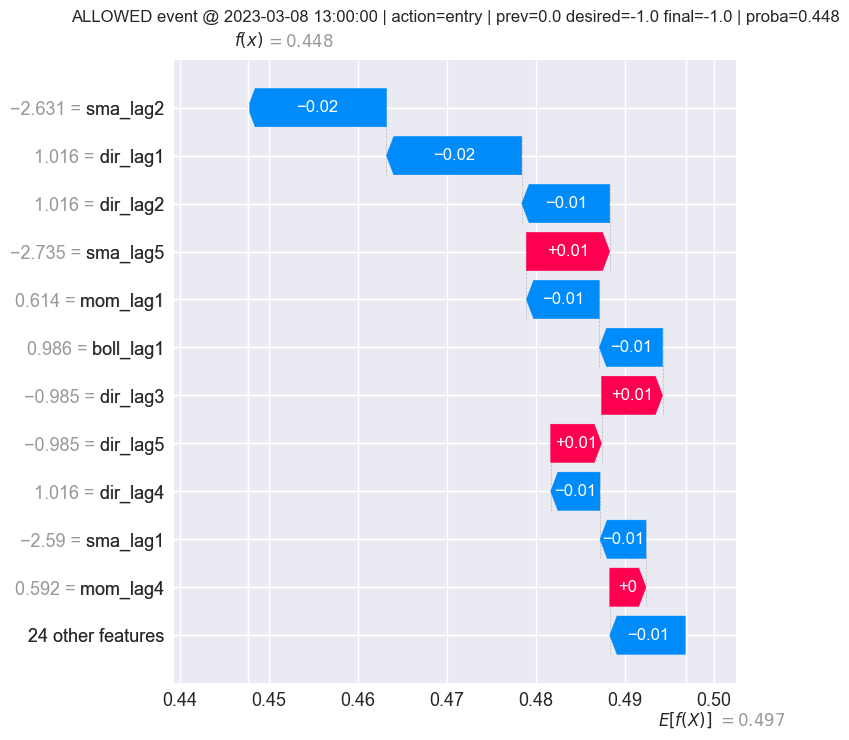


--- Explanation (ALLOWED entry/flip) ---
prev=0.0, desired=-1.0, final=-1.0
proba=0.448, shap_sum=-0.0492, top1_abs=0.0156
shap_threshold=0.0142
top features: sma_lag2(-0.0156), dir_lag1(-0.0152), dir_lag2(-0.0099)
checks: proba=True direction=True magnitude=True top1_ok=True
DECISION: ALLOW


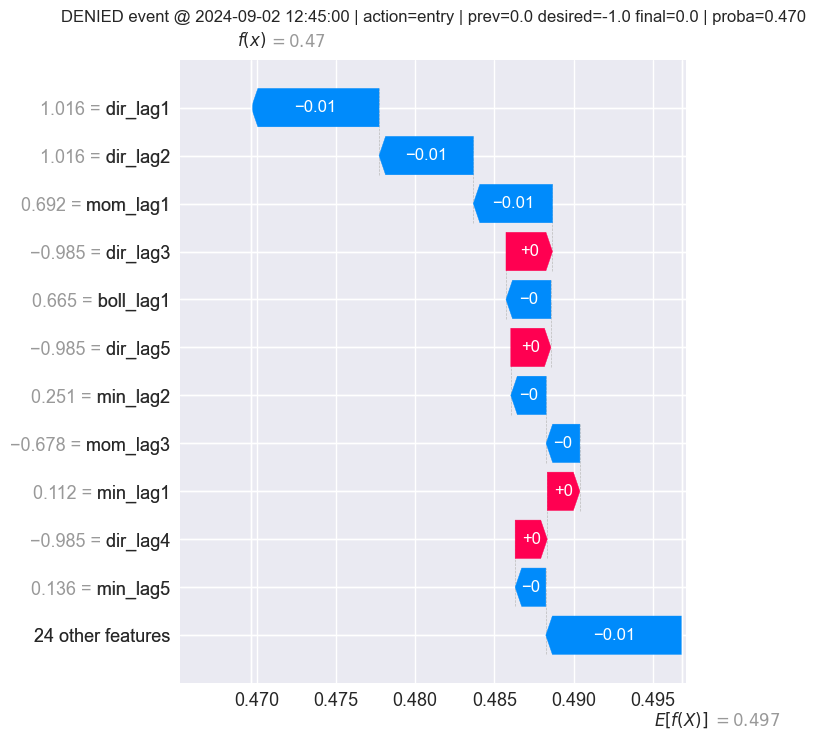


--- Explanation (DENIED entry/flip) ---
prev=0.0, desired=-1.0, final=0.0
proba=0.470, shap_sum=-0.0272, top1_abs=0.0081
shap_threshold=0.0142
top features: dir_lag1(-0.0081), dir_lag2(-0.0060), mom_lag1(-0.0050)
checks: proba=False direction=True magnitude=False top1_ok=False
DECISION: DENY


In [74]:
# Waterfall plots: one random ALLOWED entry/flip and one random DENIED entry/flip

def _get_expected_value(exp):
    ev = getattr(exp, "expected_value", 0.0)
    if isinstance(ev, (list, tuple, np.ndarray)):
        ev = ev[0]
    return float(np.array(ev).reshape(()))


def waterfall_for_event(event_time, label):
    x = test_s.loc[event_time, col].values
    shap_values = explainer.shap_values(x.reshape(1, -1), check_additivity=False)
    sv = _extract_shap_vector(shap_values)
    base = _get_expected_value(explainer)

    exp = shap.Explanation(
        values=sv,
        base_values=base,
        data=x,
        feature_names=col,
    )

    meta = gate_log_df.loc[event_time]
    title = (
        f"{label} event @ {event_time} | action={meta['action']} | "
        f"prev={meta['prev_pos']} desired={meta['desired_pos']} final={meta['final_pos']} | proba={meta['proba']:.3f}"
    )

    plt.figure(figsize=(10, 5))
    shap.plots.waterfall(exp, max_display=12, show=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(42)

# We want cases where the gate actually matters: entries or flips (not exits)
entry_like = gate_log_df["action"].isin(["entry", "flip"]) & (gate_log_df["desired_pos"].astype(float) != 0)

allowed_candidates = gate_log_df[entry_like & (gate_log_df["allow"])].index

denied_candidates = gate_log_df[entry_like & (~gate_log_df["allow"])].index

if len(allowed_candidates) > 0:
    t_allowed = allowed_candidates[rng.integers(0, len(allowed_candidates))]
    waterfall_for_event(t_allowed, "ALLOWED")
    print("\n--- Explanation (ALLOWED entry/flip) ---")
    print(gate_log_df.loc[t_allowed, "explanation"])
else:
    print("No ALLOWED entry/flip events available to plot.")

if len(denied_candidates) > 0:
    t_denied = denied_candidates[rng.integers(0, len(denied_candidates))]
    waterfall_for_event(t_denied, "DENIED")
    print("\n--- Explanation (DENIED entry/flip) ---")
    print(gate_log_df.loc[t_denied, "explanation"])
else:
    print("No DENIED entry/flip events available to plot.")

## Additional XAI Visualisations (MSc-ready)

This block produces four groups of figures:

1) **Global feature importance** (SHAP beeswarm + bar)
2) **Local explanations** (already shown above via waterfall plots)
3) **Gate behavior summary** (allowed vs denied distributions + top-driver frequency)
4) **Regime / time stability** (rolling mean absolute SHAP for top features)

Notes:
- SHAP for deep models is compute-heavy. These cells intentionally compute SHAP on a **sample** to keep runtime practical.
- To make results reproducible, a fixed RNG seed is used for sampling.

In [75]:
# ---- SHAP sampling utilities (used by multiple plots) ----

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Control how many points to explain (trade-off: quality vs runtime)
GLOBAL_SHAP_SAMPLES = 1200      # for global beeswarm+bar
REGIME_SHAP_SAMPLES = 2000      # for rolling stability
SHAP_BATCH = 200                # batch size for explainer

# Choose where to sample from:
# - For "global" interpretation across all timestamps, sample from test_s.
# - For "trade-centric" interpretation, sample from trade events only.
USE_TRADE_EVENTS_FOR_GLOBAL = False


def _extract_shap_matrix(shap_values):
    """Return a (n_samples, n_features) matrix from DeepExplainer output."""
    if isinstance(shap_values, list):
        arr = shap_values[0]
    else:
        arr = shap_values
    return np.array(arr)


def compute_shap_for_index(index, *, batch_size=SHAP_BATCH):
    """
    Compute SHAP values for rows in `index` using `test_s[col]` and the global `explainer`.
    Returns: X (n, d), S (n, d)
    """
    X = test_s.loc[index, col].values
    S_chunks = []

    for start in range(0, len(index), batch_size):
        end = min(start + batch_size, len(index))
        xb = X[start:end]
        sv = explainer.shap_values(xb, check_additivity=False)
        S_chunks.append(_extract_shap_matrix(sv))

    S = np.vstack(S_chunks) if len(S_chunks) else np.empty((0, len(col)))
    return X, S


def _sample_index_from_pool(pool_index, n):
    pool_index = np.array(pool_index)
    if len(pool_index) <= n:
        return pool_index
    take = rng.choice(len(pool_index), size=n, replace=False)
    return pool_index[take]


# Build sampling pools
trade_event_idx = gate_log_df.index  # when the baseline strategy changed position
all_test_idx = test.index

global_pool = trade_event_idx if USE_TRADE_EVENTS_FOR_GLOBAL else all_test_idx

# Samples for plots
idx_global = _sample_index_from_pool(global_pool, GLOBAL_SHAP_SAMPLES)
idx_regime = _sample_index_from_pool(trade_event_idx, REGIME_SHAP_SAMPLES)

print("Global SHAP sample size:", len(idx_global), "(trade-centric:" , USE_TRADE_EVENTS_FOR_GLOBAL, ")")
print("Regime SHAP sample size:", len(idx_regime), "(trade-event-only)")

Global SHAP sample size: 1200 (trade-centric: False )
Regime SHAP sample size: 850 (trade-event-only)


C:\Users\Mohit\AppData\Local\Temp\ipykernel_32172\3717092105.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(Sg, Xg, feature_names=col, show=False, max_display=20)
d:\anaconda3\envs\mlops_test\lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x600 with 0 Axes>

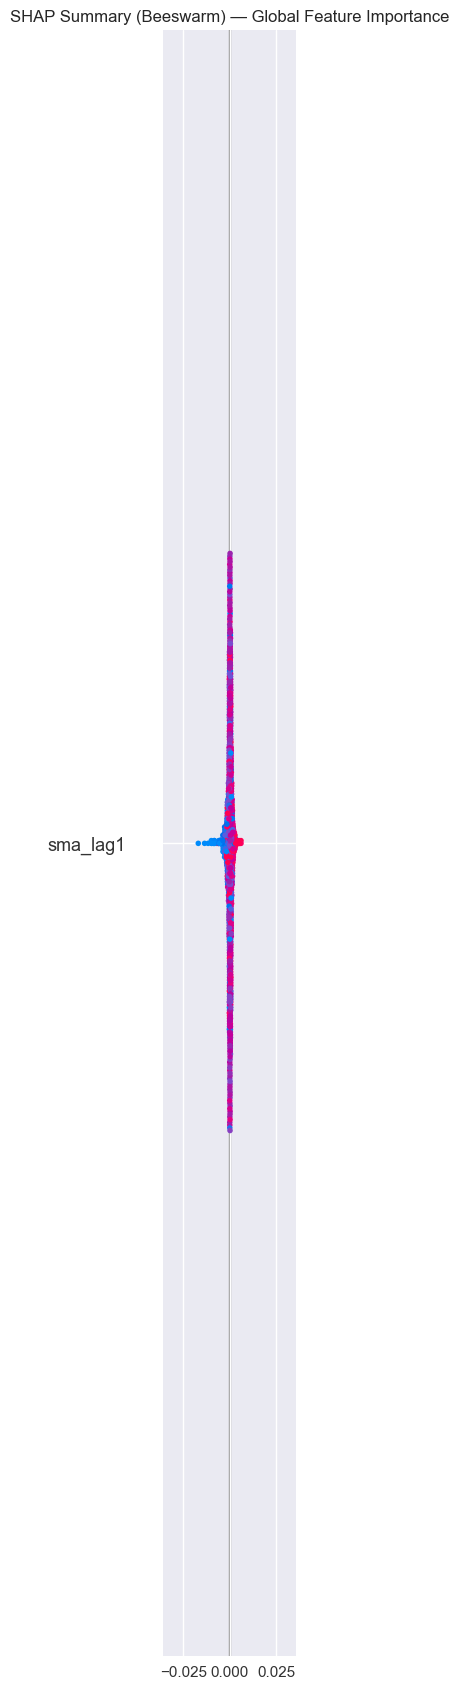

C:\Users\Mohit\AppData\Local\Temp\ipykernel_32172\3717092105.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(Sg, Xg, feature_names=col, plot_type="bar", show=False, max_display=20)
d:\anaconda3\envs\mlops_test\lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


<Figure size 1000x600 with 0 Axes>

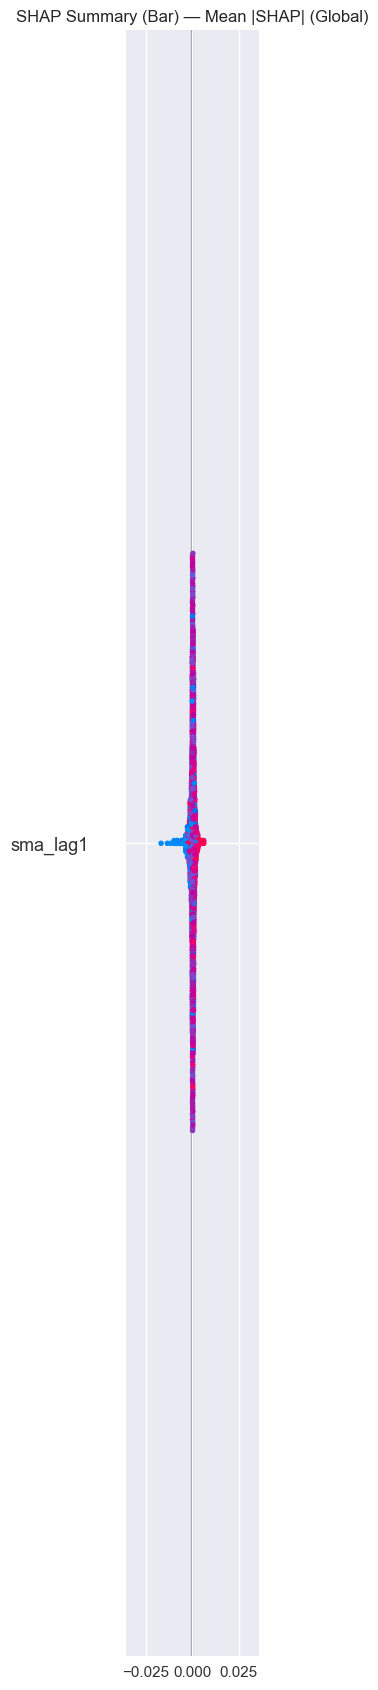

TypeError: only integer scalar arrays can be converted to a scalar index

In [76]:
# ---- 1) Global importance: beeswarm + bar ----

Xg, Sg = compute_shap_for_index(idx_global)

plt.figure(figsize=(10, 6))
shap.summary_plot(Sg, Xg, feature_names=col, show=False, max_display=20)
plt.title("SHAP Summary (Beeswarm) — Global Feature Importance")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(Sg, Xg, feature_names=col, plot_type="bar", show=False, max_display=20)
plt.title("SHAP Summary (Bar) — Mean |SHAP| (Global)")
plt.tight_layout()
plt.show()

# Identify top features for downstream regime plots
mean_abs = np.mean(np.abs(Sg), axis=0)
topk = 8
top_features_global = [col[i] for i in np.argsort(mean_abs)[::-1][:topk]]
print("Top global features (by mean |SHAP|):", top_features_global)

In [67]:
model

<Sequential name=sequential, built=True>

In [68]:
mu

price        1.12358
spread       0.00016
returns     -0.00000
dir          0.49229
sma         -0.00002
boll        -0.00659
min         -0.00207
max          0.00209
mom         -0.00000
vol          0.00044
sma_lag1    -0.00002
sma_lag2    -0.00002
sma_lag3    -0.00002
sma_lag4    -0.00002
sma_lag5    -0.00002
boll_lag1   -0.00661
boll_lag2   -0.00664
boll_lag3   -0.00666
boll_lag4   -0.00668
boll_lag5   -0.00670
min_lag1    -0.00207
min_lag2    -0.00207
min_lag3    -0.00207
min_lag4    -0.00207
min_lag5    -0.00207
max_lag1     0.00209
max_lag2     0.00209
max_lag3     0.00209
max_lag4     0.00209
max_lag5     0.00209
mom_lag1    -0.00000
mom_lag2    -0.00000
mom_lag3    -0.00000
mom_lag4    -0.00000
mom_lag5    -0.00000
vol_lag1     0.00044
vol_lag2     0.00044
vol_lag3     0.00044
vol_lag4     0.00044
vol_lag5     0.00044
dir_lag1     0.49230
dir_lag2     0.49230
dir_lag3     0.49230
dir_lag4     0.49229
dir_lag5     0.49228
dtype: float64

In [69]:
std

price       0.05947
spread      0.00010
returns     0.00050
dir         0.49994
sma         0.00237
boll        1.41934
min         0.00227
max         0.00224
mom         0.00028
vol         0.00025
sma_lag1    0.00237
sma_lag2    0.00237
sma_lag3    0.00237
sma_lag4    0.00237
sma_lag5    0.00237
boll_lag1   1.41934
boll_lag2   1.41934
boll_lag3   1.41934
boll_lag4   1.41934
boll_lag5   1.41934
min_lag1    0.00227
min_lag2    0.00227
min_lag3    0.00227
min_lag4    0.00227
min_lag5    0.00227
max_lag1    0.00224
max_lag2    0.00224
max_lag3    0.00224
max_lag4    0.00224
max_lag5    0.00224
mom_lag1    0.00028
mom_lag2    0.00028
mom_lag3    0.00028
mom_lag4    0.00028
mom_lag5    0.00028
vol_lag1    0.00025
vol_lag2    0.00025
vol_lag3    0.00025
vol_lag4    0.00025
vol_lag5    0.00025
dir_lag1    0.49994
dir_lag2    0.49994
dir_lag3    0.49994
dir_lag4    0.49994
dir_lag5    0.49994
dtype: float64

In [70]:
model.save("DNN_model.keras")

In [71]:
import pickle

In [53]:
params = {"mu":mu, "std":std}

In [54]:
params

{'mu': price        1.12358
 spread       0.00016
 returns     -0.00000
 dir          0.49229
 sma         -0.00002
 boll        -0.00659
 min         -0.00207
 max          0.00209
 mom         -0.00000
 vol          0.00044
 sma_lag1    -0.00002
 sma_lag2    -0.00002
 sma_lag3    -0.00002
 sma_lag4    -0.00002
 sma_lag5    -0.00002
 boll_lag1   -0.00661
 boll_lag2   -0.00664
 boll_lag3   -0.00666
 boll_lag4   -0.00668
 boll_lag5   -0.00670
 min_lag1    -0.00207
 min_lag2    -0.00207
 min_lag3    -0.00207
 min_lag4    -0.00207
 min_lag5    -0.00207
 max_lag1     0.00209
 max_lag2     0.00209
 max_lag3     0.00209
 max_lag4     0.00209
 max_lag5     0.00209
 mom_lag1    -0.00000
 mom_lag2    -0.00000
 mom_lag3    -0.00000
 mom_lag4    -0.00000
 mom_lag5    -0.00000
 vol_lag1     0.00044
 vol_lag2     0.00044
 vol_lag3     0.00044
 vol_lag4     0.00044
 vol_lag5     0.00044
 dir_lag1     0.49230
 dir_lag2     0.49230
 dir_lag3     0.49230
 dir_lag4     0.49229
 dir_lag5     0.49228
 dty

In [55]:
pickle.dump(params, open("params.pkl", "wb"))